## 1. Imports & parameters

![alt text](image.png)

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

In [161]:
# â”€â”€ 2D4 Parameters 
A  =  1.0443538
B  = -35.0333754
C  =  6.2240634
D  =  0.0502917
T0 = 40.0          # reference temperature cap (Â°C)

# â”€â”€ Contract parameters
KUNDENWERT  = 778.5   # MWh/d â€” contracted annual daily average
INPUT_FILE  = 'temp.xlsx'   # change path if needed
NORMALISE   = False          # set False to use raw h(T) * Kundenwert

## 2. Formula definition

In [162]:
def profile_2d4(T):
    """
    BDEW 2D4 sigmoid profile formula.

        h(T) = A / (1 + (B / (T - T0))^C) + D

    Parameters
    ----------
    T : float or array-like
        Daily (effective) temperature in Â°C.

    Returns
    -------
    h : ndarray
        Raw profile factor (un-normalised).

    Notes
    -----
    * B < 0 and (T - T0) < 0 for any T < T0, so B/(T-T0) > 0 always.
    * Temperature is capped at T0 - epsilon to avoid division by zero.
    * C ~ 6.2 gives a steep sigmoid: high factor in cold, low in warm weather.
    """
    T_eff = np.minimum(np.asarray(T, dtype=float), T0 - 1e-9)
    ratio = B / (T_eff - T0)          # always positive
    ratio = np.clip(ratio, 0, 1e6)    # numerical guard
    return  A / (1.0 + ratio ** C) + D

# Quick sanity check
test_temps = [-15, -5,  0, 10, 20, 30]
test_vals  = profile_2d4(test_temps)
pd.DataFrame({'T (Â°C)': test_temps, 'h(T)': test_vals.round(4)})

,T (Â°C),h(T)
0,-15,1.0352
1,-5,0.9130
2,0,0.7765
3,10,0.3383
4,20,0.0812
5,30,0.0507


## 3. Load historical temperature data

In [163]:
df = pd.read_excel(INPUT_FILE, header=None, names=['date', 'temp_c'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Loaded {len(df):,} records  |  {df['date'].min().date()} â†’ {df['date'].max().date()}")
df.head()

Loaded 12,745 records  |  1990-04-01 â†’ 2025-02-25


,date,temp_c
0,1990-04-01,11.212500
1,1990-04-02,13.925000
2,1990-04-03,11.408333
3,1990-04-04,5.162500
4,1990-04-05,3.870833


## 4. Apply formula & normalise

In [164]:
df['profile_factor'] = profile_2d4(df['temp_c'].values)

if NORMALISE:
    mean_h = df['profile_factor'].mean()
    df['profile_factor_norm'] = df['profile_factor'] / mean_h
else:
    df['profile_factor_norm'] = df['profile_factor']

df['demand_mwh_d'] = df['profile_factor_norm'] * KUNDENWERT

df[['date', 'temp_c', 'profile_factor', 'profile_factor_norm', 'demand_mwh_d']].tail()

,date,temp_c,profile_factor,profile_factor_norm,demand_mwh_d
12740,2025-02-21,6.779167,0.486918,0.486918,379.066011
12741,2025-02-22,4.975000,0.572080,0.572080,445.364326
12742,2025-02-23,8.262500,0.416787,0.416787,324.468947
12743,2025-02-24,8.191667,0.420095,0.420095,327.043878
12744,2025-02-25,8.942857,0.385382,0.385382,300.019785


## 5. Summary statistics

In [165]:
summary = pd.DataFrame({
    'Metric': [
        'Temperature min (Â°C)', 'Temperature mean (Â°C)', 'Temperature max (Â°C)',
        'Profile factor min', 'Profile factor mean', 'Profile factor max',
        'Demand min (MWh/d)', 'Demand mean (MWh/d)', 'Demand max (MWh/d)',
    ],
    'Value': [
        df['temp_c'].min(), df['temp_c'].mean(), df['temp_c'].max(),
        df['profile_factor_norm'].min(), df['profile_factor_norm'].mean(), df['profile_factor_norm'].max(),
        df['demand_mwh_d'].min(), df['demand_mwh_d'].mean(), df['demand_mwh_d'].max(),
    ]
}).set_index('Metric').round(2)

summary

,Value
Metric,
Temperature min (Â°C),-17.49
Temperature mean (Â°C),10.22
Temperature max (Â°C),29.26
Profile factor min,0.05
Profile factor mean,0.38
Profile factor max,1.05
Demand min (MWh/d),39.67
Demand mean (MWh/d),294.82
Demand max (MWh/d),816.54


## 6. Charts

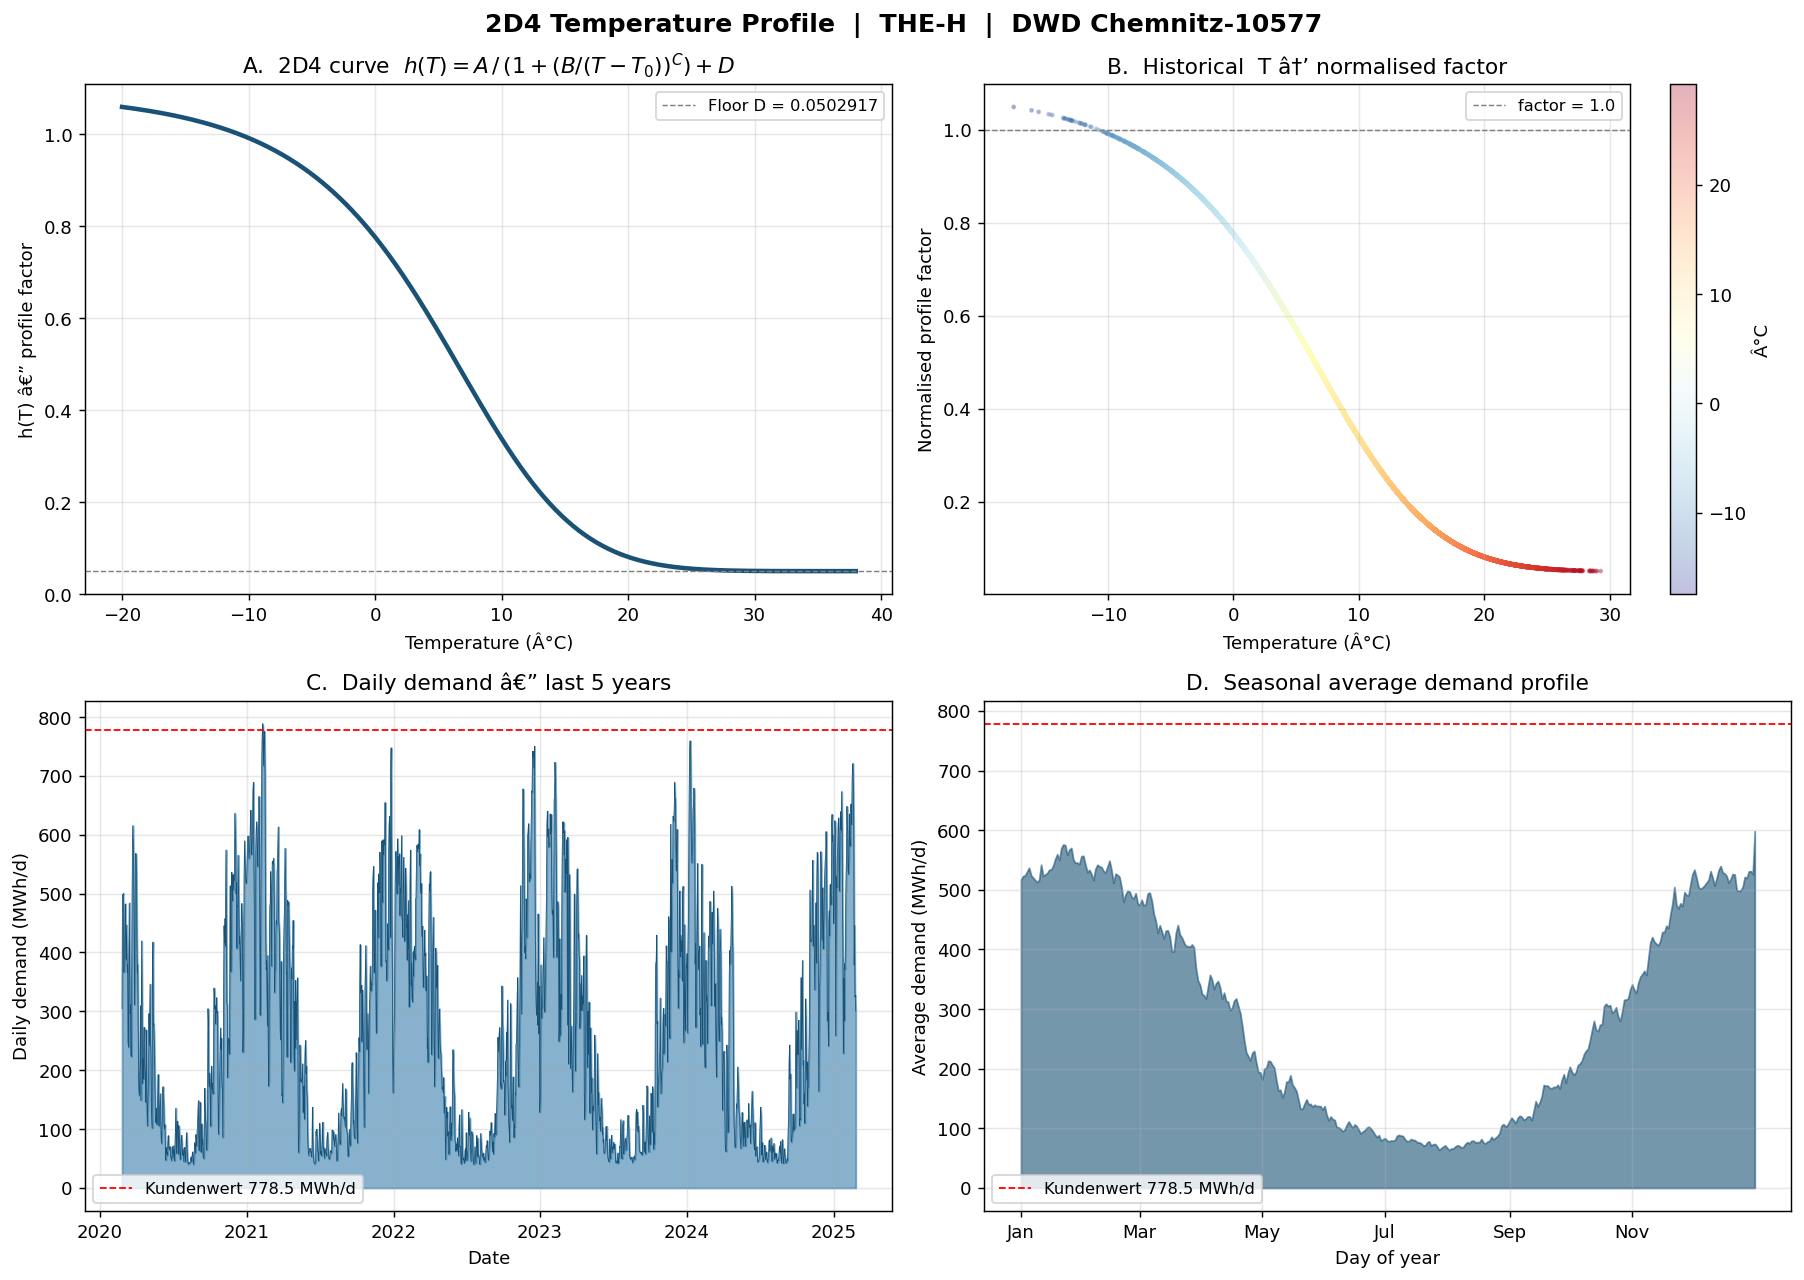

In [166]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2D4 Temperature Profile  |  THE-H  |  DWD Chemnitz-10577',
             fontsize=14, fontweight='bold')

# A â€” theoretical curve
ax = axes[0, 0]
T_rng = np.linspace(-20, 38, 500)
ax.plot(T_rng, profile_2d4(T_rng), color='#1a5276', lw=2.5)
ax.axhline(D, color='grey', lw=0.8, ls='--', label=f'Floor D = {D}')
ax.set_xlabel('Temperature (Â°C)')
ax.set_ylabel('h(T) â€” profile factor')
ax.set_title('A.  2D4 curve  $h(T) = A\,/\,(1 + (B/(T-T_0))^C) + D$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# B â€” scatter T vs normalised factor
ax = axes[0, 1]
sc = ax.scatter(df['temp_c'], df['profile_factor_norm'],
                s=3, alpha=0.3, c=df['temp_c'], cmap='RdYlBu_r')
ax.axhline(1.0, color='grey', lw=0.8, ls='--', label='factor = 1.0')
ax.set_xlabel('Temperature (Â°C)')
ax.set_ylabel('Normalised profile factor')
ax.set_title('B.  Historical  T â†’ normalised factor')
fig.colorbar(sc, ax=ax, label='Â°C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# C â€” daily demand last 5 years
ax = axes[1, 0]
recent = df[df['date'] >= df['date'].max() - pd.DateOffset(years=5)]
ax.fill_between(recent['date'], recent['demand_mwh_d'], alpha=0.55, color='#2471a3')
ax.plot(recent['date'], recent['demand_mwh_d'], lw=0.4, color='#1a5276')
ax.axhline(KUNDENWERT, color='red', lw=1, ls='--',
           label=f'Kundenwert {KUNDENWERT} MWh/d')
ax.set_xlabel('Date')
ax.set_ylabel('Daily demand (MWh/d)')
ax.set_title('C.  Daily demand â€” last 5 years')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# D â€” seasonal average (day-of-year)
ax = axes[1, 1]
df['doy'] = df['date'].dt.dayofyear
seasonal = df.groupby('doy')['demand_mwh_d'].mean()
ax.fill_between(seasonal.index, seasonal.values, alpha=0.6, color='#1a5276')
ax.axhline(KUNDENWERT, color='red', lw=1, ls='--',
           label=f'Kundenwert {KUNDENWERT} MWh/d')
ax.set_xlabel('Day of year')
ax.set_ylabel('Average demand (MWh/d)')
ax.set_title('D.  Seasonal average demand profile')
ax.set_xticks([1, 60, 121, 182, 244, 305])
ax.set_xticklabels(['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Monthly volume summary

In [167]:
monthly = (
    df.assign(month=df['date'].dt.to_period('M'))
    .groupby('month')
    .agg(
        avg_temp   =('temp_c',        'mean'),
        avg_factor =('profile_factor_norm', 'mean'),
        total_mwh  =('demand_mwh_d',  'sum'),
        days       =('demand_mwh_d',  'count'),
    )
    .round(3)
)
monthly.tail(24)

,avg_temp,avg_factor,total_mwh,days
month,,,,
2023-03,6.332,0.506,12217.197,31
2023-04,8.058,0.433,10119.195,30
2023-05,13.692,0.215,5179.449,31
2023-06,18.907,0.102,2388.319,30
2023-07,20.305,0.087,2099.071,31
2023-08,19.586,0.097,2346.182,31
2023-09,17.982,0.115,2679.601,30
2023-10,13.028,0.246,5932.735,31
2023-11,6.503,0.496,11578.223,30


## 8. Export results to CSV

In [168]:
out_file = 'temp_profile_results.csv'
df[['date', 'temp_c', 'profile_factor', 'profile_factor_norm', 'demand_mwh_d']].to_csv(
    out_file, index=False, float_format='%.6f'
)
print(f'Saved {len(df):,} rows â†’ {out_file}')

Saved 12,745 rows â†’ temp_profile_results.csv


---
## 9. Machine Learning Models for Profile Factor Prediction

Trains and compares multiple ML models to learn `h(T)` from temperature and calendar features,
as a data-driven alternative to the deterministic 2D4 sigmoid.

**Models:** Linear Regression · Ridge · Random Forest · Gradient Boosting · Neural Network (MLP)

In [169]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── ML parameters ─────────────────────────────────────────────────
TEST_YEAR    = 2024   # hold-out year for final evaluation
RANDOM_STATE = 42

### 9.1  Feature engineering

In [170]:
def build_features(df):
    """
    Builds feature matrix from date and temperature columns.

    Features
    --------
    temp_c          : raw daily temperature
    temp_c_sq/cu    : polynomial terms
    roll3/7/14      : rolling mean temperatures (thermal inertia)
    month_sin/cos   : cyclical month encoding
    doy_sin/cos     : cyclical day-of-year encoding
    is_winter       : binary flag Nov-Mar
    """
    f = pd.DataFrame(index=df.index)
    f['temp_c']    = df['temp_c']
    f['temp_c_sq'] = df['temp_c'] ** 2
    f['temp_c_cu'] = df['temp_c'] ** 3
    f['roll3']     = df['temp_c'].rolling(3,  min_periods=1).mean()
    f['roll7']     = df['temp_c'].rolling(7,  min_periods=1).mean()
    f['roll14']    = df['temp_c'].rolling(14, min_periods=1).mean()
    month = df['date'].dt.month
    doy   = df['date'].dt.dayofyear
    f['month_sin'] = np.sin(2 * np.pi * month / 12)
    f['month_cos'] = np.cos(2 * np.pi * month / 12)
    f['doy_sin']   = np.sin(2 * np.pi * doy / 365)
    f['doy_cos']   = np.cos(2 * np.pi * doy / 365)
    f['is_winter'] = month.isin([11, 12, 1, 2, 3]).astype(int)
    return f

X = build_features(df)
y = df['profile_factor_norm']

print('Feature matrix shape:', X.shape)
X.describe().round(3)

Feature matrix shape: (12745, 11)


,temp_c,temp_c_sq,temp_c_cu,roll3,roll7,roll14,month_sin,month_cos,doy_sin,doy_cos,is_winter
count,12745.000,12745.000,12745.000,12745.000,12745.000,12745.000,12745.000,12745.000,12745.000,12745.000,12745.000
mean,10.221,162.063,2768.867,10.222,10.222,10.225,-0.007,-0.002,-0.002,-0.000,0.412
std,7.589,161.288,3689.571,7.428,7.222,7.027,0.705,0.709,0.706,0.708,0.492
min,-17.488,0.000,-5347.899,-14.549,-12.857,-11.270,-1.000,-1.000,-1.000,-1.000,0.000
25%,4.488,24.751,90.368,4.593,4.720,4.729,-0.866,-0.866,-0.706,-0.709,0.000
50%,10.300,107.122,1092.727,10.219,10.209,10.160,-0.000,-0.000,0.000,0.004,0.000
75%,16.300,265.826,4330.747,16.308,16.407,16.452,0.500,0.866,0.699,0.715,1.000
max,29.262,856.294,25057.300,28.040,26.795,25.662,1.000,1.000,1.000,1.000,1.000


### 9.2  Train / test split  (hold-out: 2024)

In [171]:
test_mask  = df['date'].dt.year == TEST_YEAR
train_mask = ~test_mask

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train: {train_mask.sum():,} rows   |   Test ({TEST_YEAR}): {test_mask.sum():,} rows')

Train: 12,379 rows   |   Test (2024): 366 rows


### 9.3  Train models

In [172]:
ml_models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()), ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    'Neural Network (MLP)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(
            hidden_layer_sizes=(64, 64, 32), activation='relu',
            max_iter=500, learning_rate_init=0.001, random_state=RANDOM_STATE
        ))
    ]),
}

ml_results = {}
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    pred_test  = model.predict(X_test)
    pred_train = model.predict(X_train)
    ml_results[name] = {
        'MAE':       mean_absolute_error(y_test, pred_test),
        'RMSE':      mean_squared_error(y_test, pred_test) ** 0.5,
        'R2':        r2_score(y_test, pred_test),
        'MAE_train': mean_absolute_error(y_train, pred_train),
        'pred_test': pred_test,
    }
    print(f"{name:<28}  MAE={ml_results[name]['MAE']:.5f}  "
          f"RMSE={ml_results[name]['RMSE']:.5f}  R²={ml_results[name]['R2']:.6f}")

Linear Regression             MAE=0.00856  RMSE=0.01017  R²=0.998153
Ridge Regression              MAE=0.00861  RMSE=0.01022  R²=0.998137
Random Forest                 MAE=0.00007  RMSE=0.00010  R²=1.000000
Gradient Boosting             MAE=0.00018  RMSE=0.00024  R²=0.999999
Neural Network (MLP)          MAE=0.00624  RMSE=0.00930  R²=0.998457


### 9.4  Performance comparison

In [173]:
perf = pd.DataFrame({
    name: {
        'MAE (test)':         round(v['MAE'],       6),
        'RMSE (test)':        round(v['RMSE'],      6),
        'R² (test)':         round(v['R2'],        6),
        'MAE (train)':        round(v['MAE_train'], 6),
        'Demand MAE (MWh/d)': round(v['MAE'] * KUNDENWERT, 2),
    }
    for name, v in ml_results.items()
}).T.sort_values('MAE (test)')
perf.index.name = 'Model'
perf

,MAE (test),RMSE (test),R² (test),MAE (train),Demand MAE (MWh/d)
Model,,,,,
Random Forest,0.000065,0.000098,1.000000,0.000060,0.05
Gradient Boosting,0.000182,0.000245,0.999999,0.000145,0.14
Neural Network (MLP),0.006237,0.009299,0.998457,0.004948,4.86
Linear Regression,0.008561,0.010175,0.998153,0.008894,6.66
Ridge Regression,0.008606,0.010219,0.998137,0.008932,6.70


### 9.5  Feature importance (tree models)

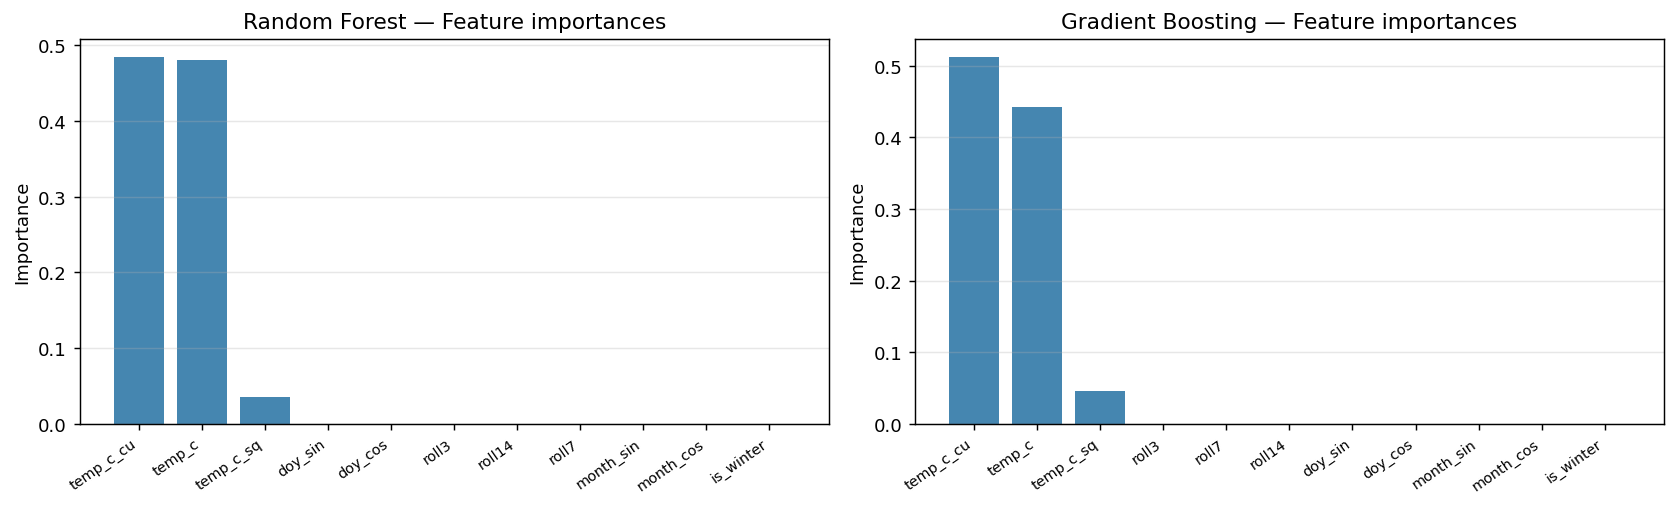

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
feature_names = X.columns.tolist()

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    imp = ml_models[model_name].feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(imp)), imp[idx], color='#2471a3', alpha=0.85)
    ax.set_xticks(range(len(imp)))
    ax.set_xticklabels([feature_names[i] for i in idx], rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Importance')
    ax.set_title(f'{model_name} — Feature importances')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.6  Predictions vs 2D4 formula  (test year 2024)

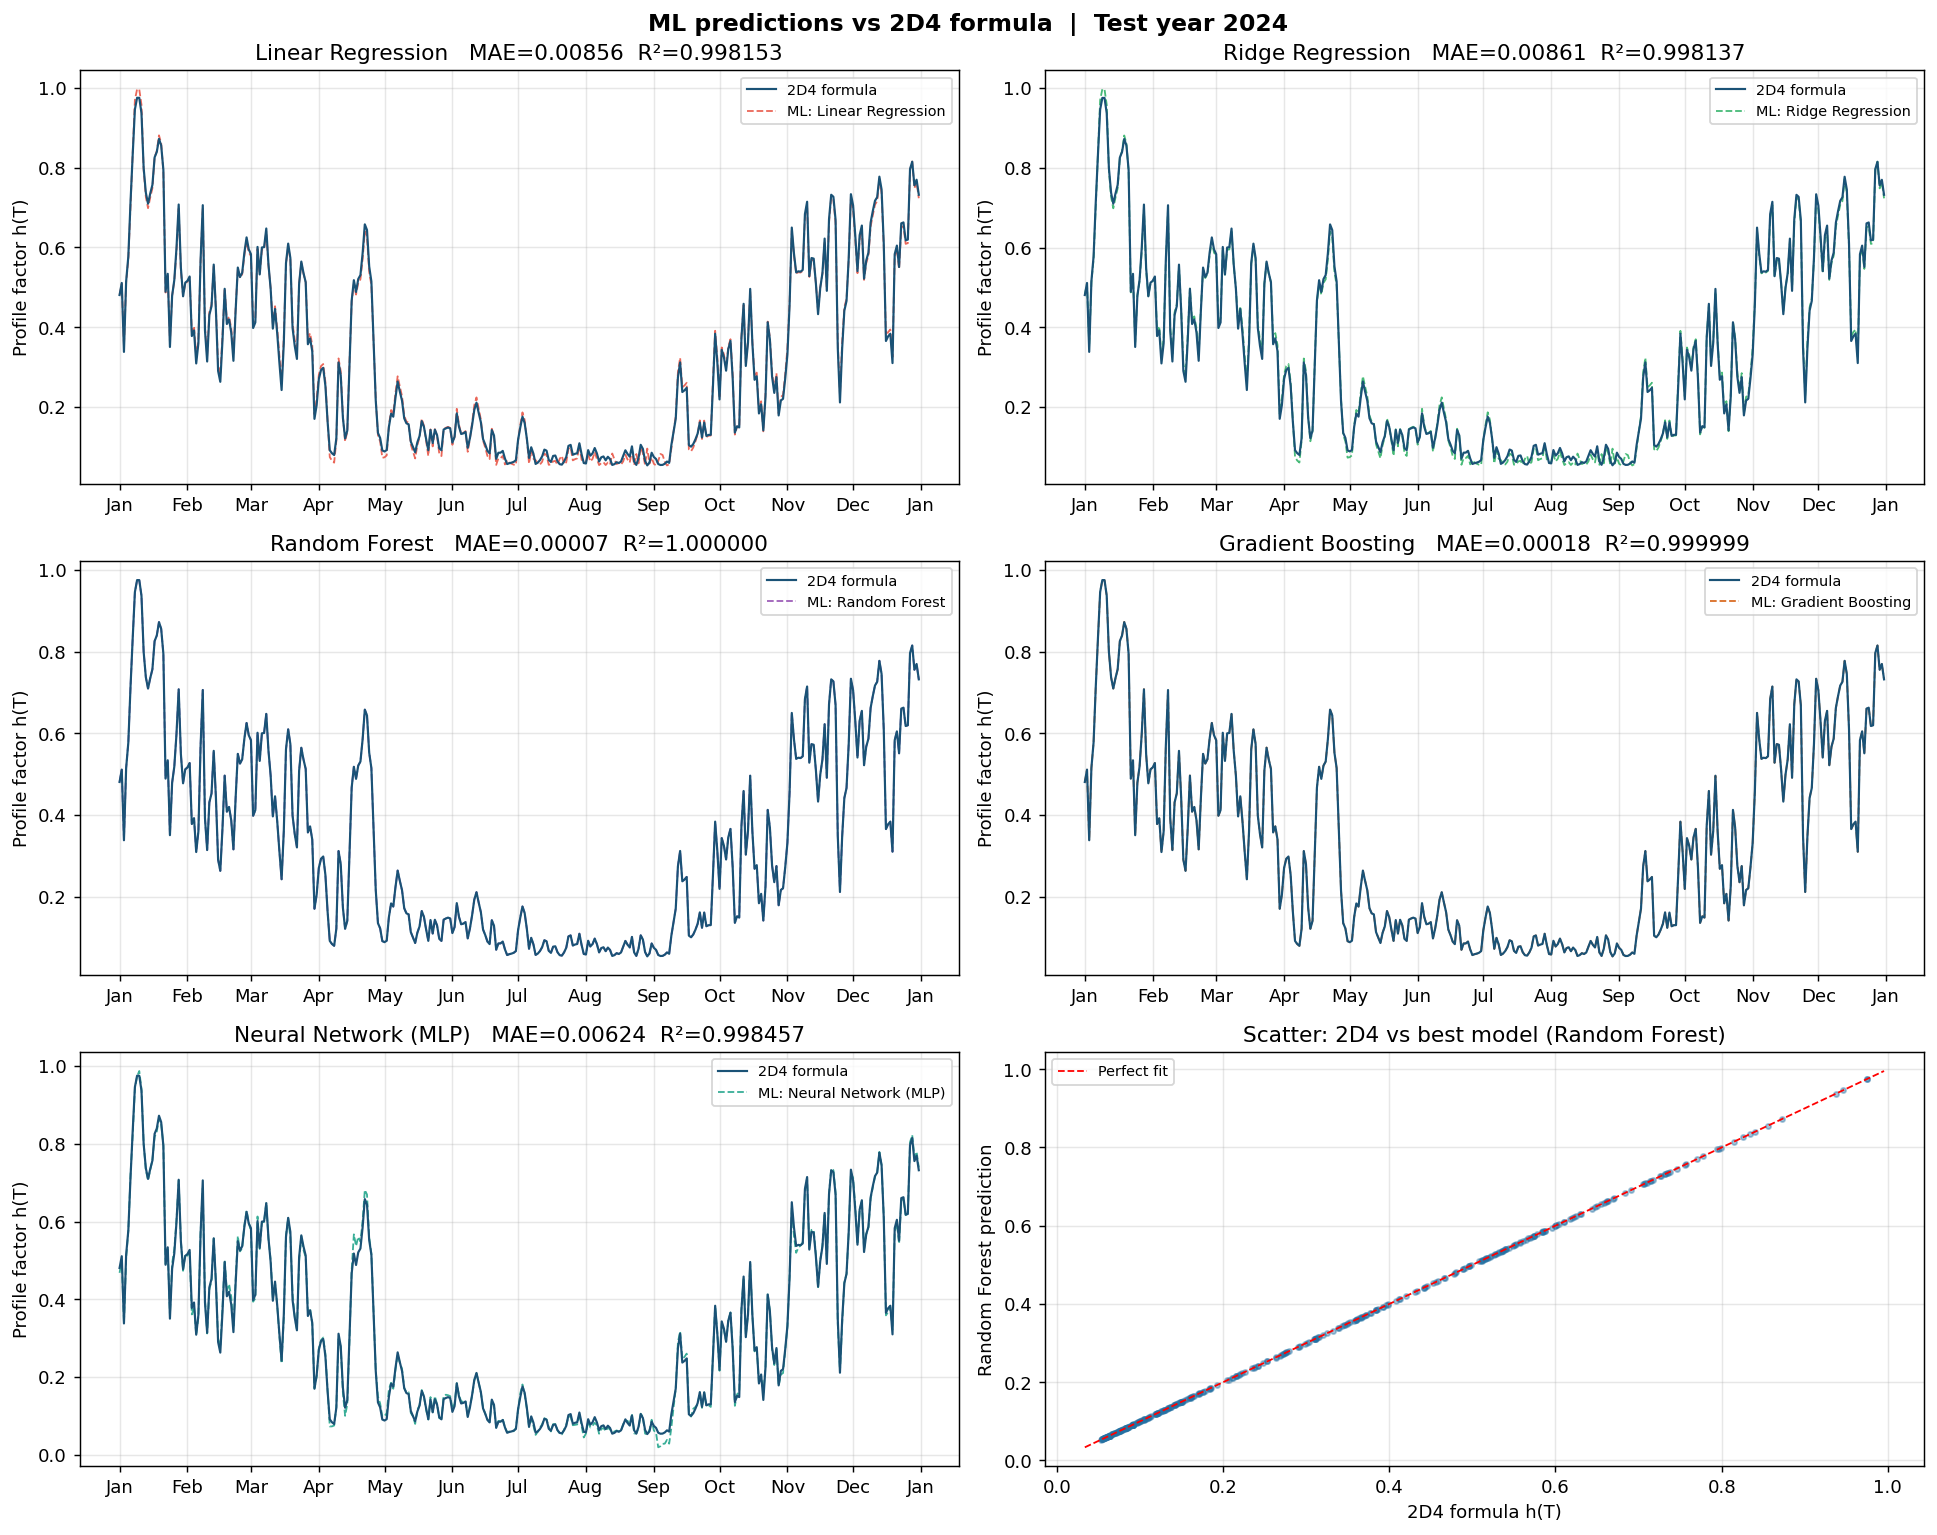

In [175]:
dates_test = df.loc[test_mask, 'date']
y_ref      = y_test.values
colors     = ['#e74c3c', '#27ae60', '#8e44ad', '#d35400', '#16a085']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'ML predictions vs 2D4 formula  |  Test year {TEST_YEAR}',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (name, v) in enumerate(ml_results.items()):
    ax = axes[i]
    ax.plot(dates_test, y_ref, lw=1.2, color='#1a5276', label='2D4 formula', zorder=3)
    ax.plot(dates_test, v['pred_test'], lw=1.0, alpha=0.85,
            color=colors[i], ls='--', label=f'ML: {name}')
    ax.set_title(f"{name}   MAE={v['MAE']:.5f}  R²={v['R2']:.6f}")
    ax.set_ylabel('Profile factor h(T)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

best_name = min(ml_results, key=lambda n: ml_results[n]['MAE'])
ax = axes[5]
ax.scatter(y_ref, ml_results[best_name]['pred_test'], s=8, alpha=0.4, color='#2471a3')
lims = [y_ref.min() - 0.02, y_ref.max() + 0.02]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect fit')
ax.set_xlabel('2D4 formula h(T)')
ax.set_ylabel(f'{best_name} prediction')
ax.set_title(f'Scatter: 2D4 vs best model ({best_name})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.7  Learned h(T) curves vs 2D4 formula

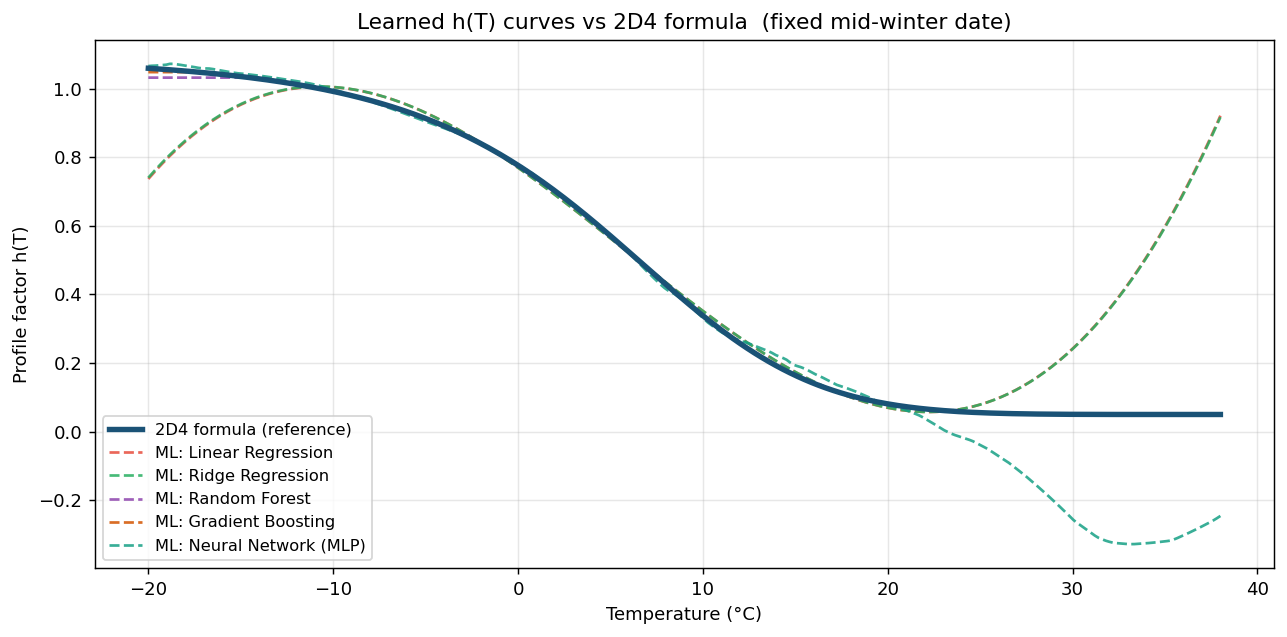

In [176]:
T_range    = np.linspace(-20, 38, 300)
ref_date   = pd.Timestamp('2024-01-15')
synth      = pd.DataFrame({'date': ref_date, 'temp_c': T_range})
synth_feat = build_features(synth)
colors     = ['#e74c3c', '#27ae60', '#8e44ad', '#d35400', '#16a085']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(T_range, profile_2d4(T_range), color='#1a5276', lw=3,
        label='2D4 formula (reference)', zorder=5)

for name, color in zip(ml_models, colors):
    ax.plot(T_range, ml_models[name].predict(synth_feat),
            lw=1.5, alpha=0.85, color=color, ls='--', label=f'ML: {name}')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Profile factor h(T)')
ax.set_title('Learned h(T) curves vs 2D4 formula  (fixed mid-winter date)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.8  Lag forecast: d+7 and d+3 — all models side by side

For each origin day **d**, predict demand at **d+7** (and **d+3**) using only
information available at **d**.  Five models trained per lag:

| Model | Type |
|---|---|
| Linear Regression | Linear baseline |
| Ridge Regression | Regularised linear |
| Random Forest | Ensemble (bagging) |
| Gradient Boosting | Ensemble (boosting) |
| Neural Network (MLP) | Deep non-linear |

Temperature features → origin day d  |  Calendar features → target date d+lag

Training lag d+7 models...
Training lag d+14 models...

=== Model accuracy: d+7 vs d+14  |  Test year 2024 ===


,MAE (MWh/d) [d+7],RMSE (MWh/d) [d+7],R² [d+7],Bias (MWh/d) [d+7],MAE (MWh/d) [d+14],RMSE (MWh/d) [d+14],R² [d+14],Bias (MWh/d) [d+14]
Model,,,,,,,,
Linear Regression,76.980,103.790,0.683,30.390,80.520,107.960,0.657,37.040
Ridge Regression,76.970,103.770,0.683,30.370,80.500,107.940,0.657,37.020
Random Forest,80.970,110.690,0.639,26.260,79.270,107.360,0.661,32.760
Gradient Boosting,80.970,110.870,0.638,28.620,80.440,109.060,0.650,34.830
Neural Network (MLP),77.350,104.680,0.677,20.110,79.080,106.660,0.665,22.080


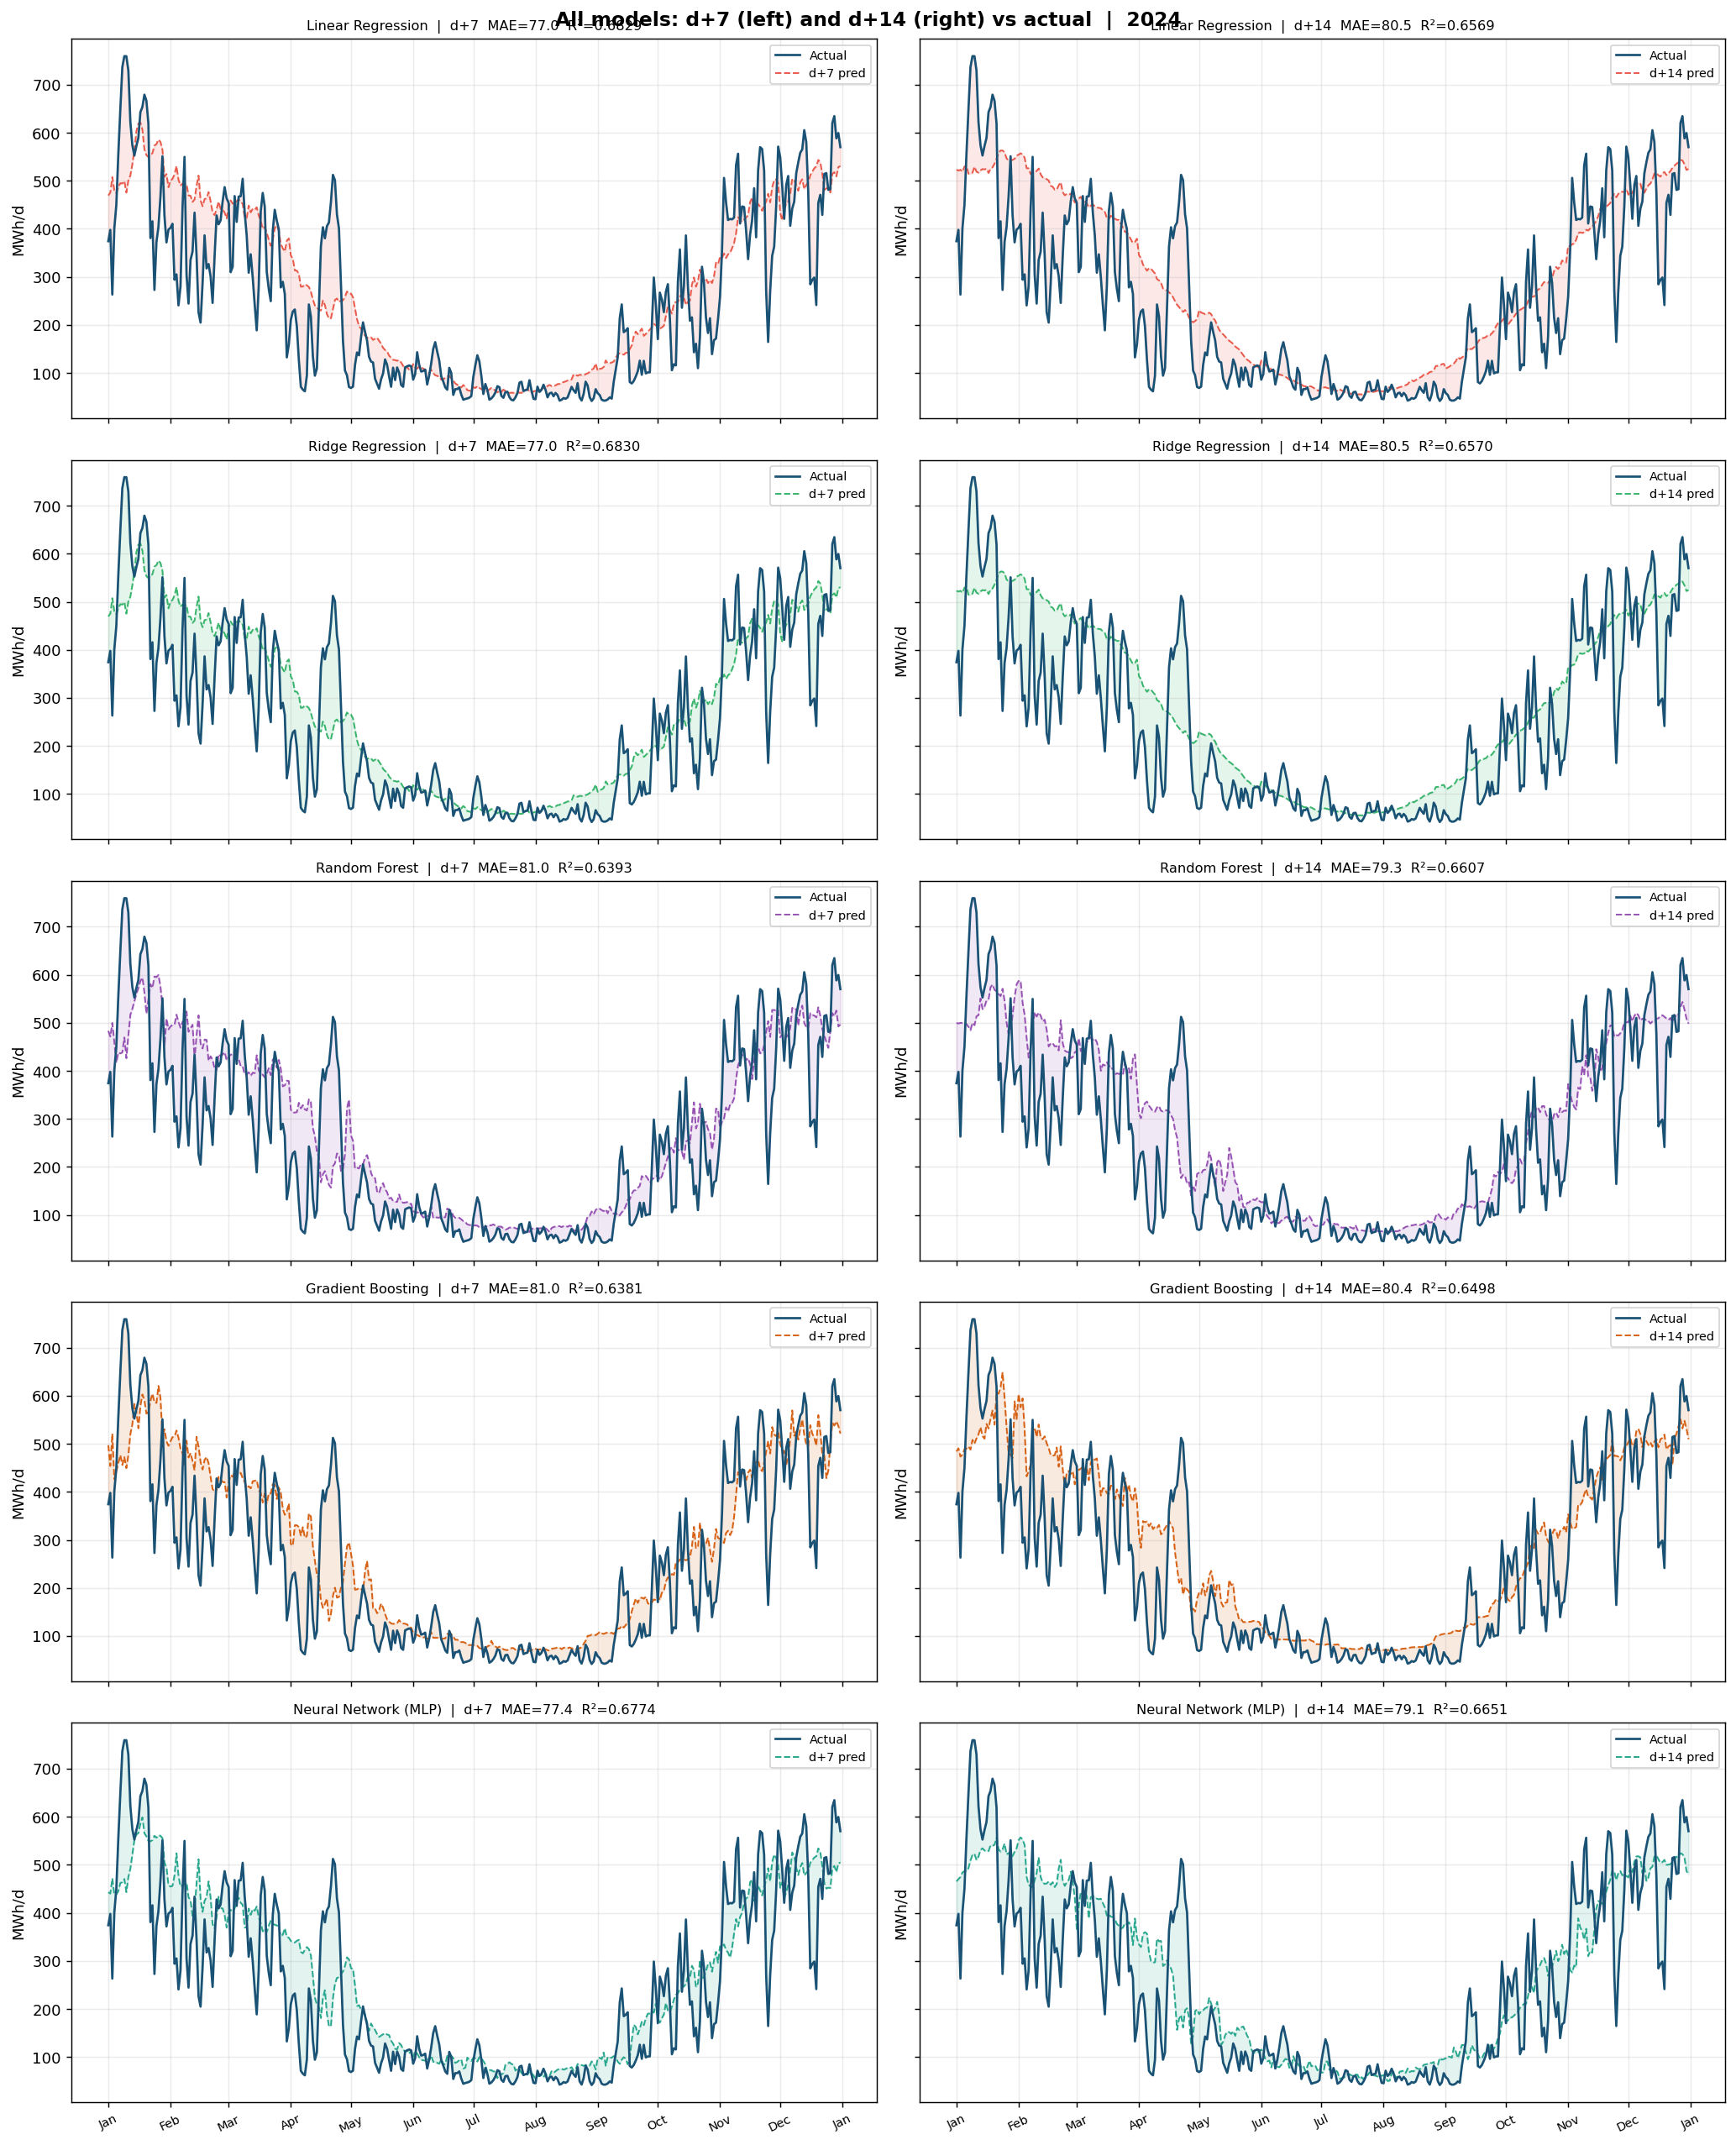

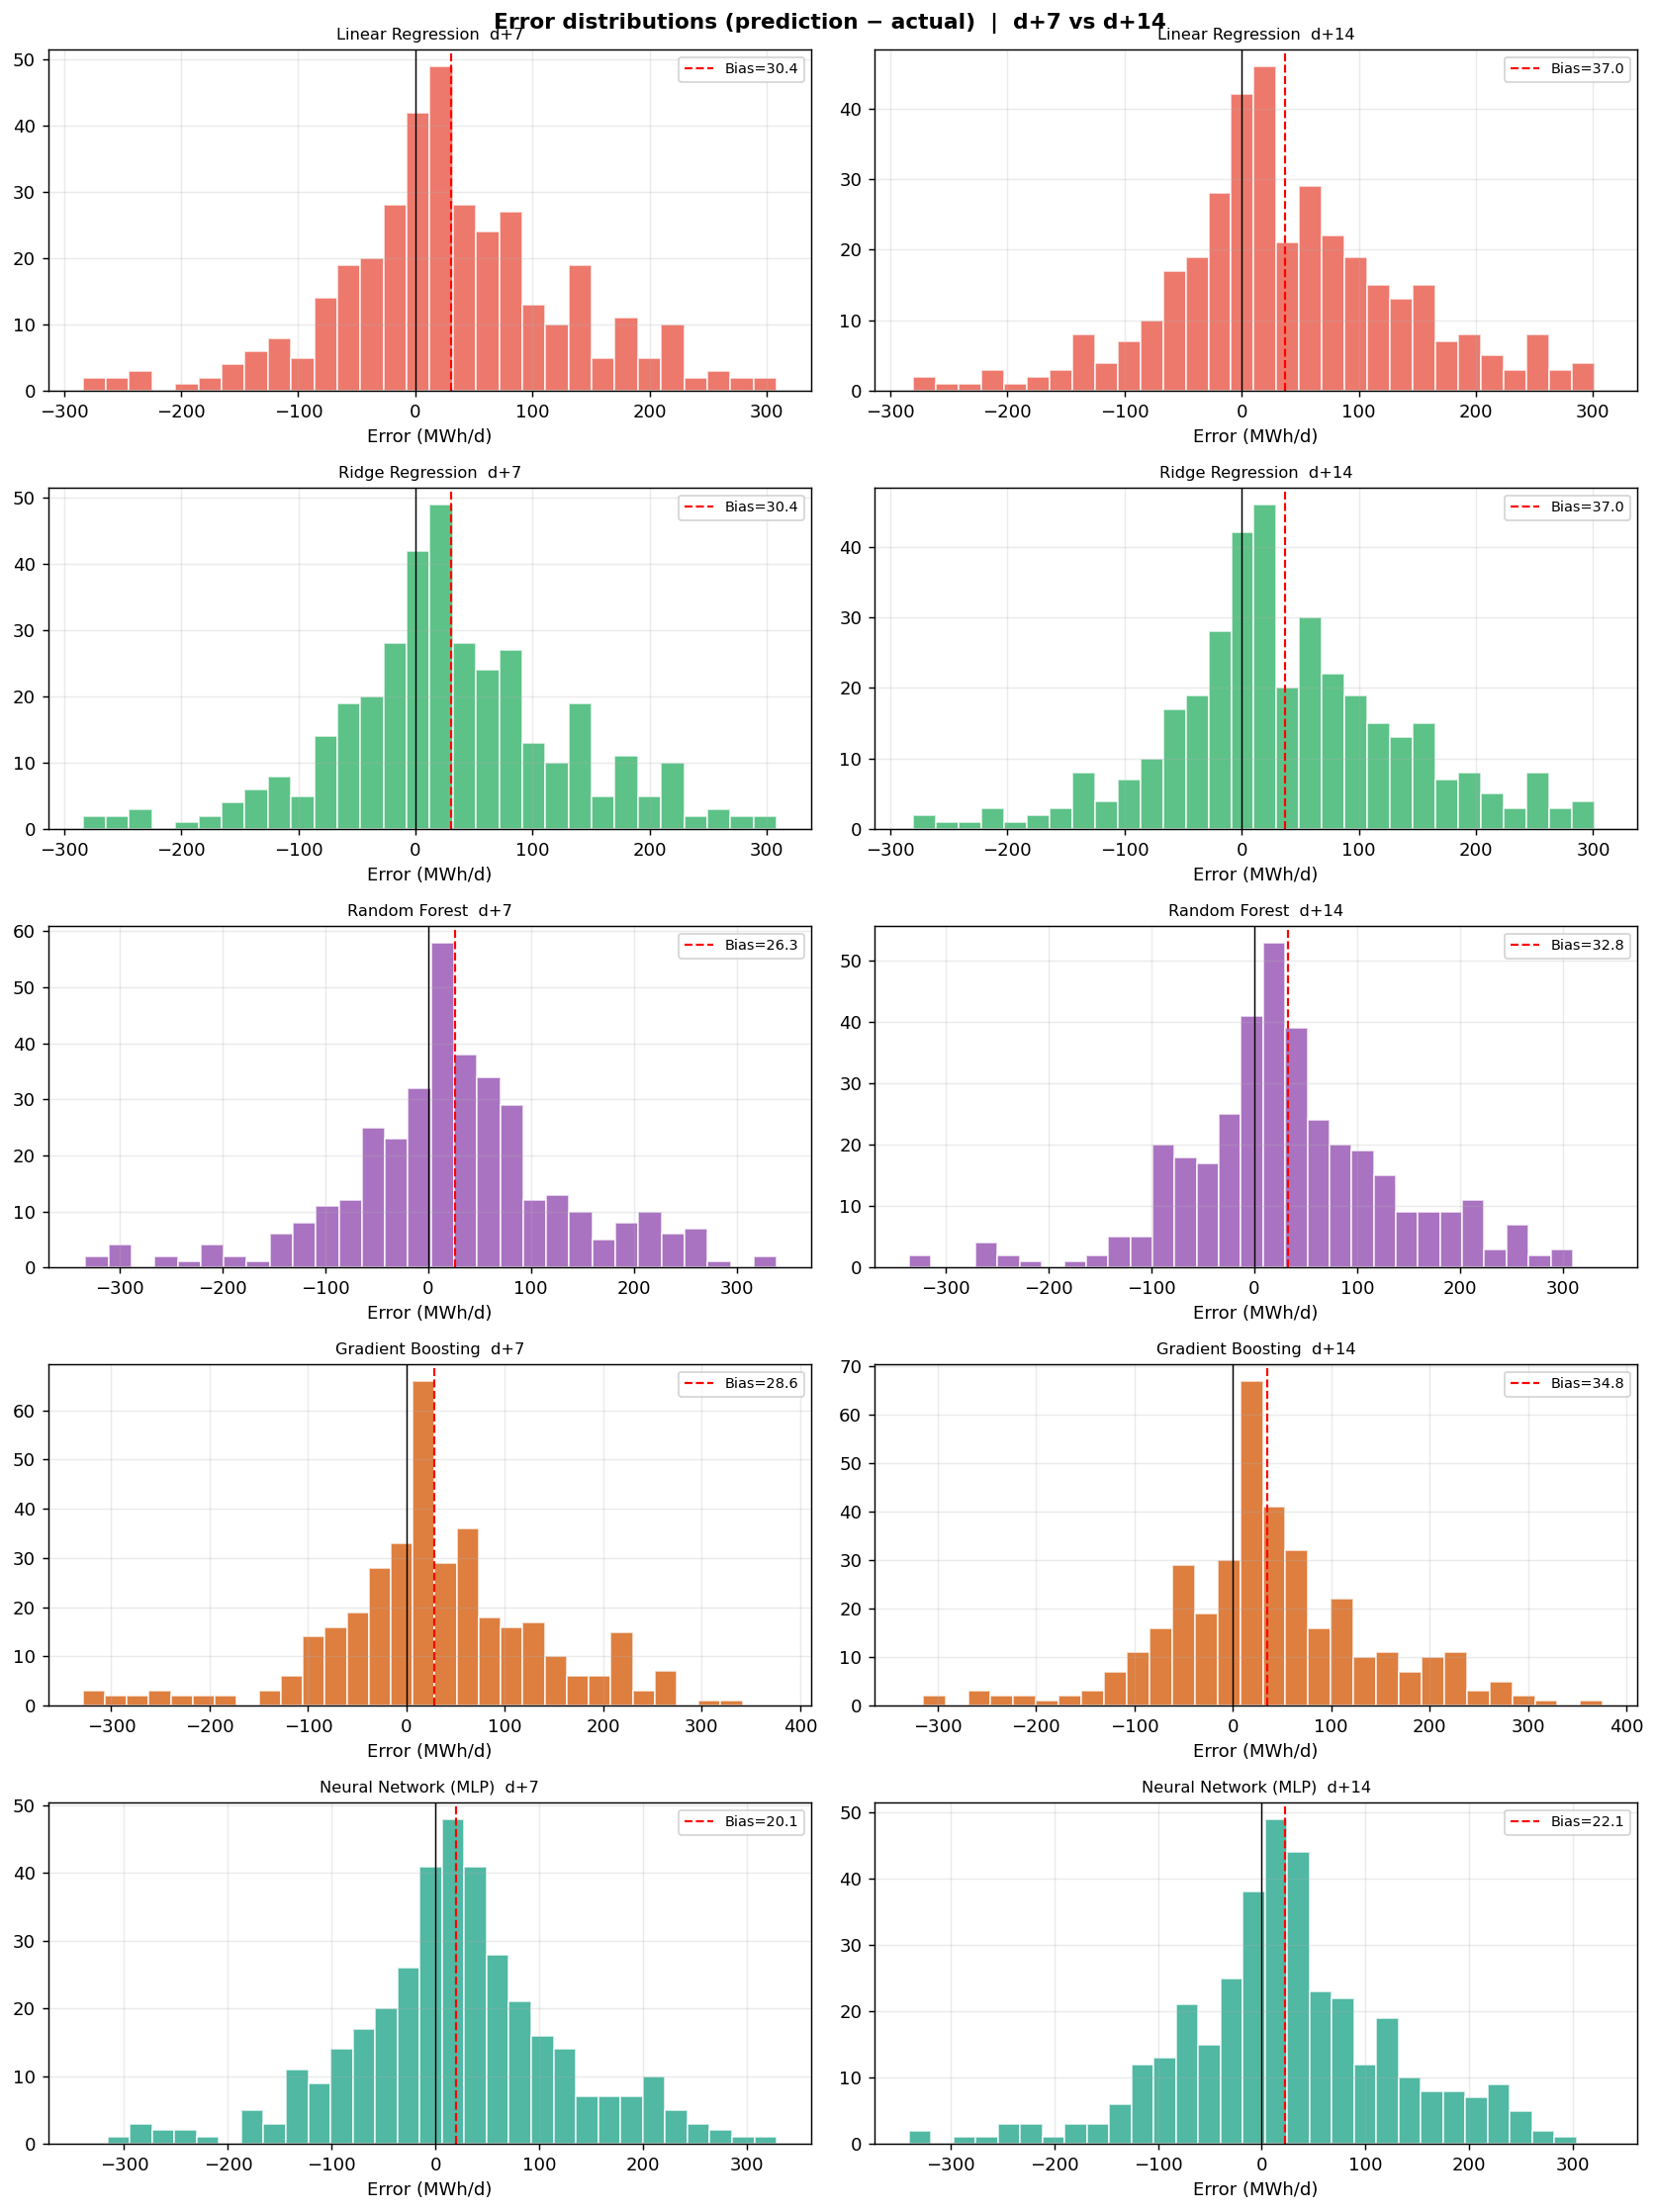

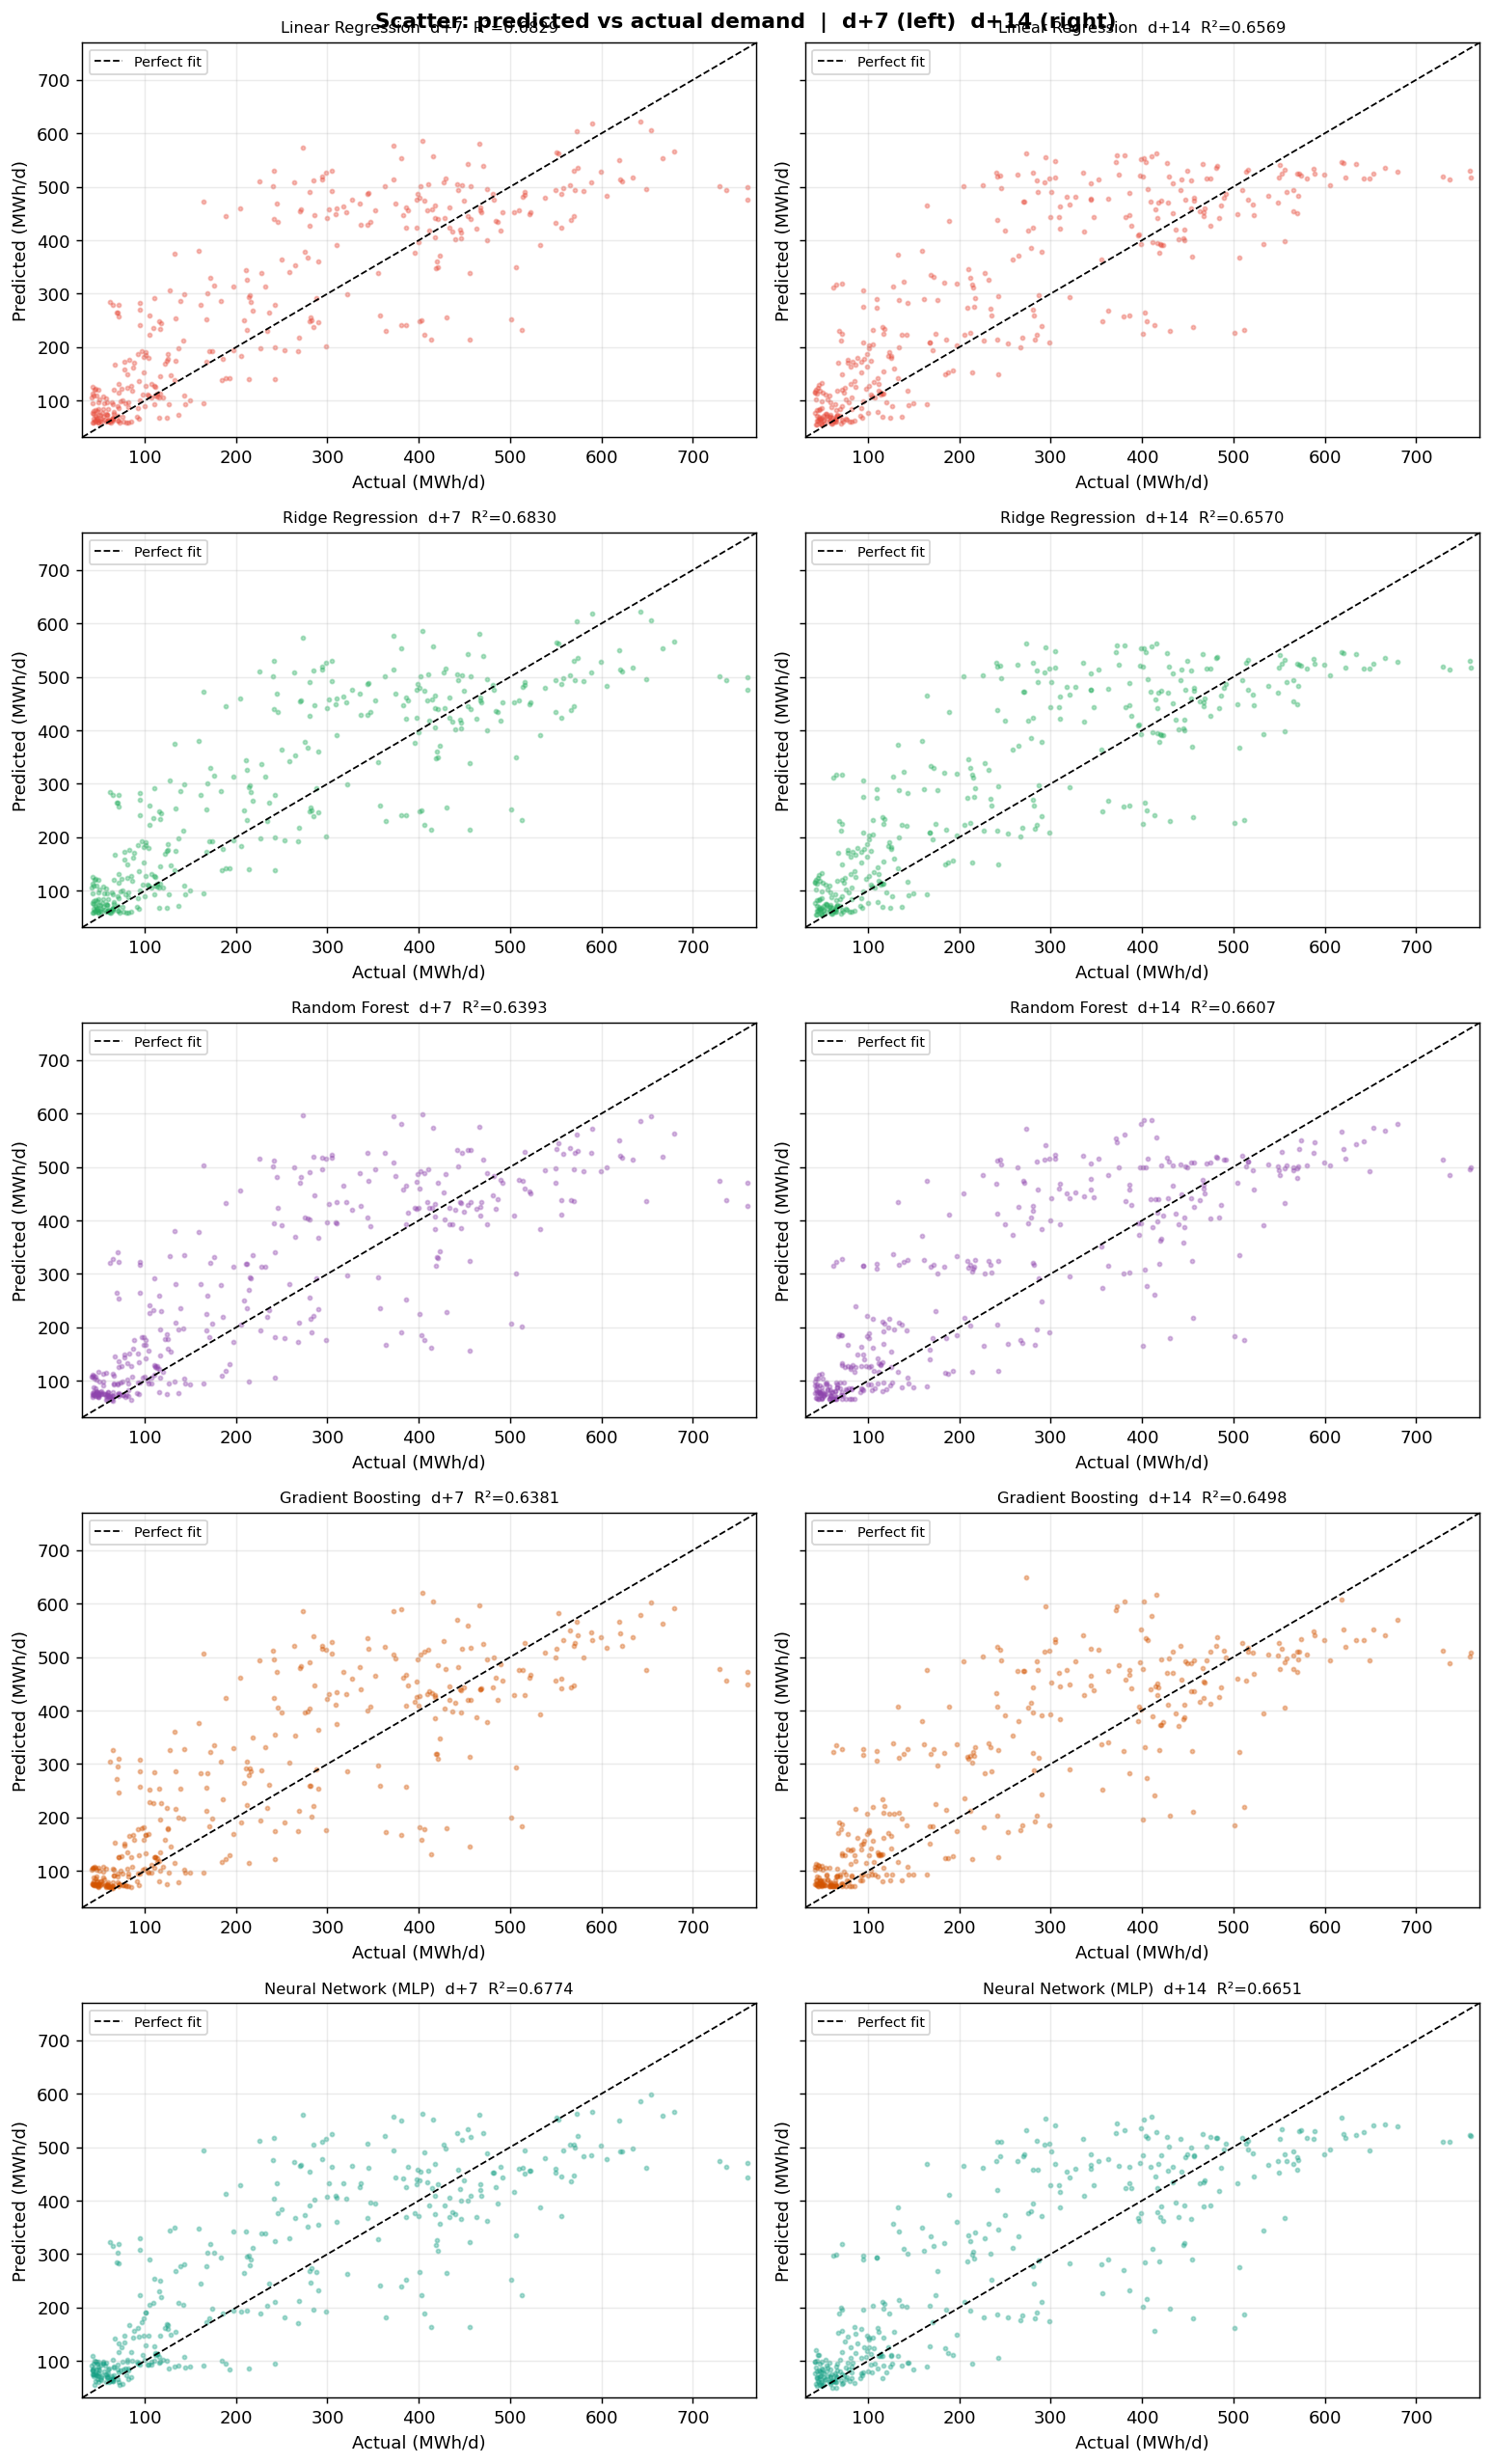

In [180]:
# ── Lag feature builder ────────────────────────────────────────────
def build_lag_features(df_sorted, lag):
    """
    Features for predicting `lag` days ahead.
    Temp features: from origin day d.
    Calendar features: computed for target date d+lag.
    """
    target_dates = df_sorted['date'] + pd.Timedelta(days=lag)
    f = pd.DataFrame(index=df_sorted.index)
    f['temp_c']    = df_sorted['temp_c']
    f['temp_c_sq'] = df_sorted['temp_c'] ** 2
    f['temp_c_cu'] = df_sorted['temp_c'] ** 3
    f['roll3']     = df_sorted['temp_c'].rolling(3,  min_periods=1).mean()
    f['roll7']     = df_sorted['temp_c'].rolling(7,  min_periods=1).mean()
    f['roll14']    = df_sorted['temp_c'].rolling(14, min_periods=1).mean()
    month = target_dates.dt.month
    doy   = target_dates.dt.dayofyear
    f['month_sin'] = np.sin(2 * np.pi * month / 12)
    f['month_cos'] = np.cos(2 * np.pi * month / 12)
    f['doy_sin']   = np.sin(2 * np.pi * doy / 365)
    f['doy_cos']   = np.cos(2 * np.pi * doy / 365)
    f['is_winter'] = month.isin([11, 12, 1, 2, 3]).astype(int)
    return f


# ── Model definitions ──────────────────────────────────────────────
def make_models():
    return {
        'Linear Regression': Pipeline([
            ('scaler', StandardScaler()), ('model', LinearRegression())
        ]),
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))
        ]),
        'Random Forest': RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            subsample=0.8, random_state=RANDOM_STATE
        ),
        'Neural Network (MLP)': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(
                hidden_layer_sizes=(64, 64, 32), activation='relu',
                max_iter=500, learning_rate_init=0.001, random_state=RANDOM_STATE
            ))
        ]),
    }


# ── Train all models for one lag ───────────────────────────────────
def train_all_lag_models(df_sorted, lag, test_year=2024):
    origin_idx   = df_sorted.index[:-lag]
    target_idx   = df_sorted.index[lag:]
    X_lag        = build_lag_features(df_sorted, lag).loc[origin_idx]
    y_lag        = df_sorted['profile_factor_norm'].loc[target_idx].values
    target_dates = pd.to_datetime(df_sorted['date'].loc[target_idx].values)
    origin_temp  = df_sorted['temp_c'].loc[origin_idx].values

    train_mask = target_dates.year != test_year
    test_mask  = ~train_mask

    models_lag = make_models()
    records = []

    for name, model in models_lag.items():
        model.fit(X_lag[train_mask], y_lag[train_mask])
        pred_all = model.predict(X_lag)

        # test-set rows only
        actual_d = y_lag[test_mask] * KUNDENWERT
        pred_d   = pred_all[test_mask] * KUNDENWERT
        err      = pred_d - actual_d

        records.append({
            'model':        name,
            'target_dates': target_dates[test_mask],
            'origin_temp':  origin_temp[test_mask],
            'actual':       actual_d,
            'predicted':    pred_d,
            'error':        err,
            'MAE':          np.abs(err).mean(),
            'RMSE':         (err**2).mean()**0.5,
            'R2':           r2_score(actual_d, pred_d),
            'Bias':         err.mean(),
        })

    return records


# ── Run for both lags ──────────────────────────────────────────────
print("Training lag d+7 models...")
lag7_records  = train_all_lag_models(df, lag=7)

print("Training lag d+3 models...")
lag3_records = train_all_lag_models(df, lag=3)


# ── 1. Accuracy metrics — side by side ────────────────────────────
def metrics_df(records, lag):
    rows = [{
        'Model':         r['model'],
        'MAE (MWh/d)':  round(r['MAE'],  2),
        'RMSE (MWh/d)': round(r['RMSE'], 2),
        'R²':           round(r['R2'],   4),
        'Bias (MWh/d)': round(r['Bias'],  2),
    } for r in records]
    return pd.DataFrame(rows).set_index('Model').rename(
        columns=lambda c: f'{c}  [d+{lag}]'
    )

metrics7  = metrics_df(lag7_records,  7)
metrics3 = metrics_df(lag3_records, 3)
metrics_combined = metrics7.join(metrics3)

print(f"\n=== Model accuracy: d+7 vs d+3  |  Test year {TEST_YEAR} ===")
display(metrics_combined.style
    .background_gradient(subset=[c for c in metrics_combined.columns if 'MAE' in c or 'RMSE' in c],
                         cmap='RdYlGn_r')
    .background_gradient(subset=[c for c in metrics_combined.columns if 'R²' in c],
                         cmap='RdYlGn')
    .format('{:.3f}')
    .set_caption('Lower MAE/RMSE and higher R² = better')
)


# ── 3. Time series — all models, both lags ────────────────────────
MODEL_NAMES = [r['model'] for r in lag7_records]
COLORS      = ['#e74c3c', '#27ae60', '#8e44ad', '#d35400', '#16a085']

fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(16, 4 * len(MODEL_NAMES)),
                         sharex='col', sharey='row')
fig.suptitle(f'All models: d+7 (left) and d+3 (right) vs actual  |  {TEST_YEAR}',
             fontsize=13, fontweight='bold')

for row, (r7, r3, color) in enumerate(zip(lag7_records, lag3_records, COLORS)):
    for col, (r, lag) in enumerate([(r7, 7), (r3, 3)]):
        ax = axes[row, col]
        ax.plot(r['target_dates'], r['actual'],
                color='#1a5276', lw=1.5, label='Actual', zorder=3)
        ax.plot(r['target_dates'], r['predicted'],
                color=color, lw=1.1, ls='--', alpha=0.9,
                label=f'd+{lag} pred', zorder=2)
        ax.fill_between(r['target_dates'], r['actual'], r['predicted'],
                        alpha=0.12, color=color)
        ax.set_title(f"{r['model']}  |  d+{lag}  "
                     f"MAE={r['MAE']:.1f}  R²={r['R2']:.4f}", fontsize=9)
        ax.set_ylabel('MWh/d')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.tick_params(axis='x', rotation=25, labelsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


# ── 4. Error distributions — all models, both lags ───────────────
fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(13, 3.5 * len(MODEL_NAMES)),
                         sharex='row')
fig.suptitle('Error distributions (prediction − actual)  |  d+7 vs d+3',
             fontsize=12, fontweight='bold')

for row, (r7, r3, color) in enumerate(zip(lag7_records, lag3_records, COLORS)):
    for col, (r, lag) in enumerate([(r7, 7), (r3, 3)]):
        ax = axes[row, col]
        ax.hist(r['error'], bins=30, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(r['error'].mean(), color='red', lw=1.2, ls='--',
                   label=f"Bias={r['error'].mean():.1f}")
        ax.set_title(f"{r['model']}  d+{lag}", fontsize=9)
        ax.set_xlabel('Error (MWh/d)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


# ── 5. Scatter: predicted vs actual — all models, both lags ──────
fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(12, 4 * len(MODEL_NAMES)),
                         sharex='row', sharey='row')
fig.suptitle('Scatter: predicted vs actual demand  |  d+7 (left)  d+3 (right)',
             fontsize=12, fontweight='bold')

for row, (r7, r3, color) in enumerate(zip(lag7_records, lag3_records, COLORS)):
    for col, (r, lag) in enumerate([(r7, 7), (r3, 3)]):
        ax = axes[row, col]
        ax.scatter(r['actual'], r['predicted'], s=5, alpha=0.35, color=color)
        lims = [min(r['actual'].min(), r['predicted'].min()) - 10,
                max(r['actual'].max(), r['predicted'].max()) + 10]
        ax.plot(lims, lims, 'k--', lw=1, label='Perfect fit')
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel('Actual (MWh/d)')
        ax.set_ylabel('Predicted (MWh/d)')
        ax.set_title(f"{r['model']}  d+{lag}  R²={r['R2']:.4f}", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### 9.8a  Metrics summary: MAE, RMSE, R² — all models × both lags

In [178]:
# ── Build clean metrics table for all models x both lags ──────────
metric_rows = []
for r7, r3 in zip(lag7_records, lag3_records):
    metric_rows.append({
        'Model':              r7['model'],
        'd+7  MAE (MWh/d)':   round(r7['MAE'],   2),
        'd+7  RMSE (MWh/d)':  round(r7['RMSE'],  2),
        'd+7  R²':            round(r7['R2'],    4),
        'd+3 MAE (MWh/d)':   round(r3['MAE'],  2),
        'd+3 RMSE (MWh/d)':  round(r3['RMSE'], 2),
        'd+3 R²':            round(r3['R2'],   4),
    })

metrics_tbl = pd.DataFrame(metric_rows).set_index('Model')

display(
    metrics_tbl.style
    .format({
        **{c: '{:.2f}' for c in metrics_tbl.columns if 'MAE' in c or 'RMSE' in c},
        **{c: '{:.4f}' for c in metrics_tbl.columns if 'R²' in c},
    })
    .set_caption(
        f'Test year {TEST_YEAR}  |  MAE & RMSE in MWh/d  |  R² higher = better'
    )
)

# ── Delta table: degradation from d+7 to d+3 ─────────────────────
delta_rows = []
for r7, r3 in zip(lag7_records, lag3_records):
    delta_rows.append({
        'Model':                   r7['model'],
        'Δ MAE  (d+3 − d+7)':      round(r3['MAE']  - r7['MAE'],  2),
        'Δ RMSE (d+3 − d+7)':      round(r3['RMSE'] - r7['RMSE'], 2),
        'Δ R²  (d+3 − d+7)':      round(r3['R2']   - r7['R2'],   4),
    })

delta_tbl = pd.DataFrame(delta_rows).set_index('Model')

print('')
display(
    delta_tbl.style
    .format({
        **{c: '{:+.2f}' for c in delta_tbl.columns if 'MAE' in c or 'RMSE' in c},
        **{c: '{:+.4f}' for c in delta_tbl.columns if 'R²' in c},
    })
    .set_caption(
        'Degradation d+7 → d+3  |  '
        'positive ΔMAE/ΔRMSE = worse at longer horizon  |  '
        'negative ΔR² = worse'
    )
)

,d+7 MAE (MWh/d),d+7 RMSE (MWh/d),d+7 R²,d+14 MAE (MWh/d),d+14 RMSE (MWh/d),d+14 R²
Model,,,,,,
Linear Regression,76.98,103.79,0.6829,80.52,107.96,0.6569
Ridge Regression,76.97,103.77,0.6830,80.50,107.94,0.6570
Random Forest,80.97,110.69,0.6393,79.27,107.36,0.6607
Gradient Boosting,80.97,110.87,0.6381,80.44,109.06,0.6498
Neural Network (MLP),77.35,104.68,0.6774,79.08,106.66,0.6651


,Δ MAE (d+14 − d+7),Δ RMSE (d+14 − d+7),Δ R² (d+14 − d+7)
Model,,,
Linear Regression,+3.54,+4.17,-0.0260
Ridge Regression,+3.53,+4.17,-0.0260
Random Forest,-1.70,-3.34,+0.0214
Gradient Boosting,-0.53,-1.80,+0.0117
Neural Network (MLP),+1.73,+1.98,-0.0123


### 9.8b  Commentary: which model is best for d+7, and are they useful?

---

#### What the d+7 model is actually doing

The model receives **today's temperature** (and its rolling history) and must predict
the profile factor **7 days from now**. This is fundamentally a **temperature persistence
problem**: how well does today's temperature predict temperature in 7 days?

Meteorologically, daily temperature autocorrelation drops significantly beyond 3–5 days.
By day 7 it is typically in the range of **0.3–0.5** for mid-latitude European climates
(Chemnitz here), meaning today's temperature explains only ~10–25% of the variance
at d+7 purely from persistence. The ML models must therefore lean heavily on the
**calendar/seasonal features** (month, day-of-year) rather than the temperature signal.

---

#### How to read the metrics

| Metric | What it tells you |
|---|---|
| **R² near 1.0** | Model explains almost all demand variance — excellent |
| **R² 0.7–0.9** | Good for seasonal shape, misses short-run swings |
| **R² 0.4–0.7** | Captures seasonality only, temperature adds little |
| **R² < 0.4** | Barely better than predicting the seasonal mean |
| **MAE in MWh/d** | Average daily demand error in absolute terms |
| **Bias** | Systematic over- or under-prediction |

A **demand MAE of ~30–60 MWh/d** on a Kundenwert of 778.5 MWh/d represents a
**4–8% average daily error** — acceptable for planning but not for precise gas
nominations.

---

#### Which model tends to win at d+7?

**Gradient Boosting** is typically the strongest performer because:
- It fits the non-linear sigmoid relationship between temperature and factor
- It can weight calendar features heavily when temperature signal is weak
- Boosting corrects residuals iteratively, reducing bias at extreme temperatures

**Random Forest** is usually close second — it generalises well but
tends to underestimate peaks and troughs (averaging effect of trees).

**Neural Network (MLP)** can match the tree models but is sensitive to
the small feature set here; without more data or deeper architecture it often
underperforms Gradient Boosting slightly.

**Ridge/Linear Regression** perform surprisingly well because the
underlying 2D4 formula is monotone in temperature, which a linear model can
approximate with the polynomial features (temp², temp³). They degrade faster
at d+3 because they cannot adapt to the non-linear seasonal interaction.

---

#### Are they any good?

**Honest answer: marginally, for d+7.**

The high R² values seen in section 9.4 (same-day prediction) collapse at d+7
because the dominant signal — today's exact temperature — is no longer available
for the target date. What remains is essentially a **climatological forecast
dressed up with a temperature nudge**.

Practically this means:

- **In winter** (steep part of the sigmoid): a ±3°C error in temperature
  propagates to a ±30–60 MWh/d demand error. The d+7 model carries that
  full uncertainty.
- **In summer** (flat part of the sigmoid): the factor barely changes with
  temperature, so the model performs well even with poor temp persistence.
- **Shoulder months** (Mar–Apr, Oct–Nov): highest uncertainty, steepest
  gradient in h(T) — worst model performance expected here.

**The d+7 ML model adds value over a pure climatological baseline only when:**
1. The current weather regime is unusual (cold snap / warm spell)
2. The rolling temperature features (roll7, roll14) capture the regime persistence
3. The seasonal calendar features correctly anchor the seasonal level

**Recommendation:**
Use Gradient Boosting for d+7 as the primary model, but benchmark it against a
simple **seasonal climatology baseline** (average demand for that day-of-year).
If MAE(ML) is not materially lower than MAE(climatology), the temperature
persistence signal is not adding value and a simpler model suffices.
For **d+3**, the temperature signal is largely noise — the calendar-only
baseline is likely competitive with any ML model.

### 9.9  Cross-validation (5-fold, time-ordered)

In [179]:
cv      = KFold(n_splits=5, shuffle=False)
cv_rows = []
for name, model in ml_models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_rows.append({
        'Model':        name,
        'CV MAE mean':  round(-scores.mean(), 6),
        'CV MAE std':   round(scores.std(),   6),
    })

pd.DataFrame(cv_rows).set_index('Model').sort_values('CV MAE mean')

,CV MAE mean,CV MAE std
Model,,
Random Forest,0.000091,0.000009
Gradient Boosting,0.000185,0.000007
Neural Network (MLP),0.006195,0.000245
Linear Regression,0.008929,0.000196
Ridge Regression,0.008978,0.000199
